<a href="https://colab.research.google.com/github/hasmmed09-ui/ai-coding-agent/blob/main/compet_ama_hesap_farkli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lightkurve tdqm

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 44.9 MB/s eta 0:00:00
  Created wheel for tdqm: filename=tdqm-0.0.1-py3-none-any.whl size=1322 sha256=f6f92f2bdeb4fa5978b8f953b07a127c848c4825bcd0a69cbb8d2800c93d22fb
  Stored in directory: /root/.cache/pip/wheels/af/02/71/aae0f7ee738abf19498353918ddae0f90a0d6ceb33

In [2]:
import shutil
import lightkurve as lk
cache_dir = lk.config.get_cache_dir()
shutil.rmtree(cache_dir)
print(f"clearing cache at: {cache_dir}")

clearing cache at: /root/.lightkurve/cache


/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
import io
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightkurve as lk
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# Fetch metadata directly from NASA Exoplanet Archive
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+kepoi_name,kepid,koi_disposition,koi_period,koi_time0bk+from+cumulative&format=csv"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

if response.status_code == 200:
    koi = pd.read_csv(io.StringIO(response.text))
    print("KOI table successfully fetched!")
else:
    raise Exception(f"Failed to download metadata: {response.status_code}")

# Filter for Confirmed/Candidate (1) vs False Positive (0)
koi = koi[koi["koi_disposition"].isin(["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"])].copy()
koi["label"] = koi["koi_disposition"].apply(lambda x: 1 if x in ["CONFIRMED", "CANDIDATE"] else 0)
koi = koi.dropna(subset=['kepid', 'koi_period', 'koi_time0bk'])

print(f"Total targets available: {len(koi)}")

KOI table successfully fetched!
Total targets available: 9564


In [5]:
import gc
import numpy as np
import pandas as pd
import lightkurve as lk
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

# --- 1. Helper Functions for 2-Channel Light Curves (Flux + Error) ---

def process_local_view_2channel(lc, period, t0, bins=201, add_noise=False):
    """
    Extracts local view centered around transit.
    Returns shape: (bins, 2) -> [Channel 0: Flux, Channel 1: Flux Uncertainty]
    """
    try:
        folded = lc.fold(period=period, epoch_time=t0)
        phase_mask = (folded.phase.value >= -0.25) & (folded.phase.value <= 0.25)
        local_folded = folded[phase_mask]

        binned = local_folded.bin(time_bin_size=period/bins)
        # Ensure flux and flux_err are numpy arrays, not masked arrays
        flux = np.asarray(binned.flux.value)
        flux_err = np.asarray(binned.flux_err.value)

        # Pad or slice to exact bin size
        if len(flux) > bins:
          flux = flux[:bins]
          flux_err = flux_err[:bins]
        elif len(flux) < bins:
          pad_len = bins - len(flux)
          flux = np.pad(flux, (0, pad_len), mode='edge')
          flux_err = np.pad(flux_err, (0, pad_len), mode='edge')


        # Normalize Flux
        flux = flux - np.nanmedian(flux)
        norm_f = np.max(np.abs(flux))
        if norm_f > 0:
            flux = flux / norm_f

        # Standardize Flux Errors
        flux_err = np.nan_to_num(flux_err)
        norm_e = np.max(flux_err)
        if norm_e > 0:
            flux_err = flux_err / norm_e

        flux = np.nan_to_num(flux)

        # Add Gaussian noise for augmentation if requested
        if add_noise:
            # Scale noise by a fraction of the maximum flux_err or a fixed small value
            noise_std = 0.01 * np.max(flux_err) # Example: 5% of max error, adjust as needed
            gaussian_noise = np.random.normal(0, noise_std, flux.shape)
            flux = flux + gaussian_noise

        # Stack into 2-channel array: (bins, 2)
        return np.stack([flux, flux_err], axis=-1)
    except Exception as e:
        print(f"    process_local_view_2channel failed: {e}")
        return None


def process_global_view_2channel(lc, period, t0, bins=2001):
    """
    Extracts full orbit global view.
    Returns shape: (bins, 2) -> [Channel 0: Flux, Channel 1: Flux Uncertainty]
    """
    try:
        folded = lc.fold(period=period, epoch_time=t0)
        binned = folded.bin(time_bin_size=period/bins)
        # Ensure flux and flux_err are numpy arrays, not masked arrays
        flux = np.asarray(binned.flux.value)
        flux_err = np.asarray(binned.flux_err.value)

        if len(flux) < bins:
            flux = np.pad(flux, (0, bins - len(flux)), mode='edge')
            flux_err = np.pad(flux_err, (0, bins - len(flux_err)), mode='edge')
        else:
            flux = flux[:bins]
            flux_err = flux_err[:bins]

        # Normalize Flux
        flux = flux - np.nanmedian(flux)
        norm_f = np.max(np.abs(flux))
        if norm_f > 0:
            flux = flux / norm_f

        # Standardize Flux Errors
        flux_err = np.nan_to_num(flux_err)
        norm_e = np.max(flux_err)
        if norm_e > 0:
            flux_err = flux_err / norm_e

        flux = np.nan_to_num(flux)

        return np.stack([flux, flux_err], axis=-1)
    except Exception as e:
        print(f"    process_global_view_2channel failed: {e}")
        return None

# --- 2. Filter & Balance Dataset ---

hacm = 1000
n_per_class = hacm // 2

confirmed_df = koi[koi["label"] == 1]
false_positive_df = koi[koi["label"] == 0]

balanced_koi = pd.concat([
    confirmed_df.sample(n=min(n_per_class, len(confirmed_df)), random_state=42),
    false_positive_df.sample(n=min(n_per_class, len(false_positive_df)), random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# Updated METADATA_COLS to reflect available columns in `koi` dataframe
METADATA_COLS = ['koi_period'] # Only koi_period is a relevant numeric feature present in `koi`

for col in METADATA_COLS:
    if col in balanced_koi.columns:
        balanced_koi[col] = balanced_koi[col].fillna(balanced_koi[col].median())

# --- 3. Processing Loop (OOD Split: Q1-12 Train vs Q13-17 Test) ---

# --- 3. Parallel Worker Function ---
import scipy.interpolate as interpolate
from concurrent.futures import ThreadPoolExecutor, as_completed

def resize_vector(vec, target_len):
  if vec is None or len(vec) < 2:
    return None

  vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)

  x_old = np.linspace(0, 1, len(vec))
  x_new = np.linspace(0, 1, target_len)

  interp_func = interpolate.interp1d(x_old, vec, kind='linear')
  return interp_func(x_new)

def fetch_and_process_target(row, metadata_cols):
        print(f"Processing KIC {int(row.kepid)}")
        search = lk.search_lightcurve(f"KIC {int(row.kepid)}", mission="Kepler", author="Kepler")
        if len(search) < 5:
            print(f"  Skipping KIC {int(row.kepid)}: Not enough light curves found ({len(search)})")
            return None

        train_search = search[:12]  # Quarters 1-12
        test_search = search[12:]   # Quarters 13-17

        if len(train_search) == 0 or len(test_search) == 0:
            print(f"  Skipping KIC {int(row.kepid)}: Not enough train or test quarters. Train: {len(train_search)}, Test: {len(test_search)}")
            return None

        train_coll = train_search.download_all()
        test_coll = test_search.download_all()

        if train_coll is None or test_coll is None:
          print(f"  Skipping KIC {int(row.kepid)}: Failed to download light curves.")
          return None


        try:
          lc_train = train_coll.stitch()
          lc_test = test_coll.stitch()
        except Exception as e:
          print(f"  Skipping KIC {int(row.kepid)}: Failed to stitch light curves. {e}")
          return None



        loc_tr = process_local_view_2channel(lc_train, period=row['koi_period'], t0=row['koi_time0bk'], bins=201)
        glob_tr = process_global_view_2channel(lc_train, period=row['koi_period'], t0=row['koi_time0bk'], bins=2001)

        loc_te = process_local_view_2channel(lc_test, period=row['koi_period'], t0=row['koi_time0bk'], bins=201)
        glob_te = process_global_view_2channel(lc_test, period=row['koi_period'], t0=row['koi_time0bk'], bins=2001)

        if loc_tr is None or glob_tr is None or loc_te is None or glob_te is None:
          print(f"  Skipping KIC {int(row.kepid)}: Failed to process local/global views.")
          return None

        metadata = row[metadata_cols].values.astype(np.float32)

        """loc_tr = resize_vector(loc_tr, 201)
        glob_tr = resize_vector(glob_tr, 2001)
        loc_te = resize_vector(loc_te, 201)
        glob_te = resize_vector(glob_te, 2001)"""

        res = {
                "train": (loc_tr, glob_tr, metadata, row['label']),
                "test": (loc_te, glob_te, metadata, row['label'])
            }


        try:
          del lc_train, lc_test, train_coll, test_coll, search
        except UnboundLocalError:
          pass
        gc.collect()
        return res


# --- 4. Robust Sequential Execution Loop (Deadlock-Proof) ---
import socket
socket.setdefaulttimeout(15.0)  # Drops hung MAST connections after 15 seconds

X_loc_train, X_glob_train, X_meta_train, y_train = [], [], [], []
X_loc_test, X_glob_test, X_meta_test, y_test = [], [], [], []

print("Processing targets sequentially...")

for _, row in tqdm(balanced_koi.iterrows(), total=len(balanced_koi)):
    try:
        result = fetch_and_process_target(row, METADATA_COLS)
        if result is not None:
            # Train split
            tr_loc, tr_glob, tr_meta, tr_y = result["train"]
            X_loc_train.append(tr_loc)
            X_glob_train.append(tr_glob)
            X_meta_train.append(tr_meta)
            y_train.append(tr_y)

            # Test split
            te_loc, te_glob, te_meta, te_y = result["test"]
            X_loc_test.append(te_loc)
            X_glob_test.append(te_glob)
            X_meta_test.append(te_meta)
            y_test.append(te_y)
    except Exception as e:
        print(f"An error occurred during processing row {row.kepid}: {e}")
        # Silently skip bad targets and move immediately to the next one
        continue

gc.collect()
print("Dataset extraction complete! Moving to training...")
# Convert arrays & scale metadata
# Convert lists to NumPy arrays safely
X_loc_train = np.array(X_loc_train)
X_glob_train = np.array(X_glob_train)
y_train = np.array(y_train)

X_loc_test = np.array(X_loc_test)
X_glob_test = np.array(X_glob_test)
y_test = np.array(y_test)

# Process metadata only if features are present
X_meta_train = np.array(X_meta_train)
X_meta_test = np.array(X_meta_test)

if X_meta_train.size == 0 or X_meta_train.shape[-1] == 0:
    # If no metadata features exist, create a dummy single-column vector of zeros
    X_meta_train = np.zeros((len(X_loc_train), 1), dtype=np.float32)
    X_meta_test = np.zeros((len(X_loc_test), 1), dtype=np.float32)
else:
    # Ensure 2D shape for scikit-learn
    if X_meta_train.ndim == 1:
        X_meta_train = X_meta_train.reshape(-1, 1)
        X_meta_test = X_meta_test.reshape(-1, 1)

    scaler = StandardScaler()
    X_meta_train = scaler.fit_transform(X_meta_train)
    X_meta_test = scaler.transform(X_meta_test)





print("\n--- Parallel OOD Quarter-Split Dataset Ready ---")
print(f"Train (Q1-12) Local: {X_loc_train.shape} | Global: {X_glob_train.shape} | Meta: {X_meta_train.shape}")
print(f"Test  (Q13-17) Local: {X_loc_test.shape} | Global: {X_glob_test.shape} | Meta: {X_meta_test.shape}")

Processing targets sequentially...


  0%|          | 0/1000 [00:00<?, ?it/s]

Processing KIC 6286633


  0%|          | 1/1000 [00:20<5:48:48, 20.95s/it]

Processing KIC 3838496


...

Processing KIC 4947556


100%|█████████▉| 999/1000 [3:18:37<00:10, 10.49s/it]

Processing KIC 7515762


100%|██████████| 1000/1000 [3:18:48<00:00, 11.93s/it]


Dataset extraction complete! Moving to training...

--- Parallel OOD Quarter-Split Dataset Ready ---
Train (Q1-12) Local: (899, 201, 2) | Global: (899, 2001, 2) | Meta: (899, 1)
Test  (Q13-17) Local: (899, 201, 2) | Global: (899, 2001, 2) | Meta: (899, 1)


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Memory Layer (Re-used for Local Branch) ---

class PhysicsAugmentedMemoryLayer(layers.Layer):
    def __init__(self, memory_size=32, feature_dim=32, orthogonality_weight=0.01, **kwargs):
        super().__init__(**kwargs)
        self.memory_size = memory_size
        self.feature_dim = feature_dim
        self.orthogonality_weight = orthogonality_weight

        # Trainable physics prototype memory bank
        self.memory = self.add_weight(
            shape=(memory_size, feature_dim),
            initializer="glorot_uniform",
            trainable=True,
            name="physics_memory_bank"
        )
        self.forget_dense = layers.Dense(feature_dim, activation="sigmoid", name="forget_gate")

    def call(self, inputs):
        # 1. L2 Normalize inputs and memory slots
        norm_inputs = tf.nn.l2_normalize(inputs, axis=-1)
        norm_memory = tf.nn.l2_normalize(self.memory, axis=-1)

        # 2. Cosine similarity & Softmax Attention
        similarity = tf.matmul(norm_inputs, norm_memory, transpose_b=True)
        attention_weights = tf.nn.softmax(similarity, axis=-1)

        # 3. Retrieve context & apply selective forget gate
        memory_context = tf.matmul(attention_weights, self.memory)
        forget_gate = self.forget_dense(inputs)
        filtered_context = memory_context * forget_gate

        # 4. PHYSICS PENALTY: Force memory slots to be orthogonal (non-redundant prototypes)
        # M @ M^T should be close to the Identity matrix I
        gram_matrix = tf.matmul(norm_memory, norm_memory, transpose_b=True)
        identity = tf.eye(self.memory_size)
        ortho_loss = tf.reduce_mean(tf.square(gram_matrix - identity))

        # Add the loss term dynamically to the layer
        self.add_loss(self.orthogonality_weight * ortho_loss)

        return layers.concatenate([inputs, filtered_context])


# --- 2. Tri-Branch Multi-Modal Architecture ---
def build_tri_branch_network(local_shape=(201, 1), global_shape=(2001, 1), meta_shape=(6,)):
    # ------------------ BRANCH 1: Local View (Transit Shape) ------------------
    input_local = layers.Input(shape=local_shape, name="input_local")
    x_loc = layers.Conv1D(16, 11, activation="relu", kernel_regularizer=regularizers.l2(0.001))(input_local)
    x_loc = layers.MaxPooling1D(2)(x_loc)
    x_loc = layers.Dropout(0.3)(x_loc)

    x_loc = layers.Conv1D(32, 5, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x_loc)
    x_loc = layers.MaxPooling1D(2)(x_loc)
    x_loc = layers.Dropout(0.3)(x_loc)

    x_loc = layers.Flatten()(x_loc)
    loc_features = layers.Dense(32, activation="relu")(x_loc)

    # Memory Layer on Local Features
    loc_memory_features = PhysicsAugmentedMemoryLayer(memory_size=32, feature_dim=32)(loc_features)

    # ------------------ BRANCH 2: Global View (Full Orbit) ------------------
    input_global = layers.Input(shape=global_shape, name="input_global")
    x_glob = layers.Conv1D(16, 16, activation="relu", kernel_regularizer=regularizers.l2(0.001))(input_global)
    x_glob = layers.MaxPooling1D(4)(x_glob)
    x_glob = layers.Dropout(0.3)(x_glob)

    x_glob = layers.Conv1D(32, 8, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x_glob)
    x_glob = layers.MaxPooling1D(4)(x_glob)
    x_glob = layers.Dropout(0.3)(x_glob)

    x_glob = layers.Conv1D(64, 4, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x_glob)
    x_glob = layers.MaxPooling1D(4)(x_glob)
    x_glob = layers.Dropout(0.3)(x_glob)

    x_glob = layers.Flatten()(x_glob)
    glob_features = layers.Dense(32, activation="relu")(x_glob)

    # ------------------ BRANCH 3: Metadata (Astrophysics Vector) ------------------
    input_meta = layers.Input(shape=meta_shape, name="input_metadata")
    x_meta = layers.Dense(16, activation="relu")(input_meta)
    meta_features = layers.Dense(16, activation="relu")(x_meta)

    # ------------------ FUSION & CLASSIFICATION HEAD ------------------
    fused = layers.concatenate([loc_memory_features, glob_features, meta_features])

    x_fuse = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001))(fused)
    x_fuse = layers.Dropout(0.4)(x_fuse)
    x_fuse = layers.Dense(32, activation="relu")(x_fuse)

    output = layers.Dense(1, activation="sigmoid", name="exoplanet_prediction")(x_fuse)

    model = models.Model(
        inputs=[input_local, input_global, input_meta],
        outputs=output,
        name="MultiModal_Exoplanet_Vetter"
    )
    return model

# 1. Force 3D shapes for time-series inputs: (samples, timesteps, 1)
X_loc_train = np.atleast_3d(X_loc_train)
X_loc_test = np.atleast_3d(X_loc_test)

X_glob_train = np.atleast_3d(X_glob_train)
X_glob_test = np.atleast_3d(X_glob_test)

# 2. Instantiate the network passing (timesteps, channels)
model = build_tri_branch_network(
    local_shape=(X_loc_train.shape[1], X_loc_train.shape[2]),
    global_shape=(X_glob_train.shape[1], X_glob_train.shape[2]),
    meta_shape=(X_meta_train.shape[1],) # Corrected to pass as a tuple
)
model.summary()

Model: "MultiModal_Exoplanet_Vetter"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_global        │ (None, 2001, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 1986, 16)  │        528 │ input_global[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_local         │ (None, 201, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_12    │ (None, 496, 16)   │          0 │ conv1d_12[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 191, 16)   │        368 │ input_local[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 496, 16)   │          0 │ max_pooling1d_12… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 95, 16)    │          0 │ conv1d_10[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 489, 32)   │      4,128 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 95, 16)    │          0 │ max_pooling1d_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_13    │ (None, 122, 32)   │          0 │ conv1d_13[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 91, 32)    │      2,592 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 122, 32)   │          0 │ max_pooling1d_13… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 45, 32)    │          0 │ conv1d_11[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 119, 64)   │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 45, 32)    │          0 │ max_pooling1d_11… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_14    │ (None, 29, 64)    │          0 │ conv1d_14[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1440)      │          0 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 29, 64)    │          0 │ max_pooling1d_14… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_metadata      │ (None, 1)         │          0 │ -               

 Total params: 133,137 (520.07 KB)

 Trainable params: 133,137 (520.07 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
import tensorflow as tf
from tensorflow.keras import optimizers, losses, metrics, callbacks

# --- 1. Compile Model ---
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.BinaryCrossentropy(),
    metrics=[
        metrics.BinaryAccuracy(name="accuracy"),
        metrics.AUC(name="auc"),
        metrics.Precision(name="precision"),
        metrics.Recall(name="recall")
    ]
)

# --- 2. Callbacks for Stable Training ---
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# --- 3. Fit Model on OOD Quarter Split ---
print("Training on Quarters 1-12 & Validating on Quarters 13-17 (OOD)...")

history = model.fit(
    x={
        "input_local": X_loc_train,
        "input_global": X_glob_train,
        "input_metadata": X_meta_train
    },
    y=y_train,
    validation_data=(
        {
            "input_local": X_loc_test,
            "input_global": X_glob_test,
            "input_metadata": X_meta_test
        },
        y_test
    ),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

Training on Quarters 1-12 & Validating on Quarters 13-17 (OOD)...
Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 243ms/step - accuracy: 0.5039 - auc: 0.4826 - loss: 0.8513 - precision: 0.5147 - recall: 0.7140 - val_accuracy: 0.5606 - val_auc: 0.6452 - val_loss: 0.8225 - val_precision: 0.5450 - val_recall: 0.9118 - learning_rate: 0.0010
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.5250 - auc: 0.5508 - loss: 0.8080 - precision: 0.5281 - recall: 0.7677 - val_accuracy: 0.4828 - val_auc: 0.7033 - val_loss: 0.7916 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.5706 - auc: 0.6103 - loss: 0.7734 - precision: 0.5808 - recall: 0.6108 - val_accuracy: 0.5662 - val_auc: 0.7160 - val_loss: 0.7528 - val_precision: 0.6963 - val_recall: 0.2860 - learning_rate: 0.0010
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.6418 - auc: 0.6871 - loss: 0.7135 - precision: 0.6405 - recal

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
     SOTA EVALUATION METRICS
ROC-AUC Score                  : 0.7739
PR-AUC (Precision-Recall Area) : 0.7357


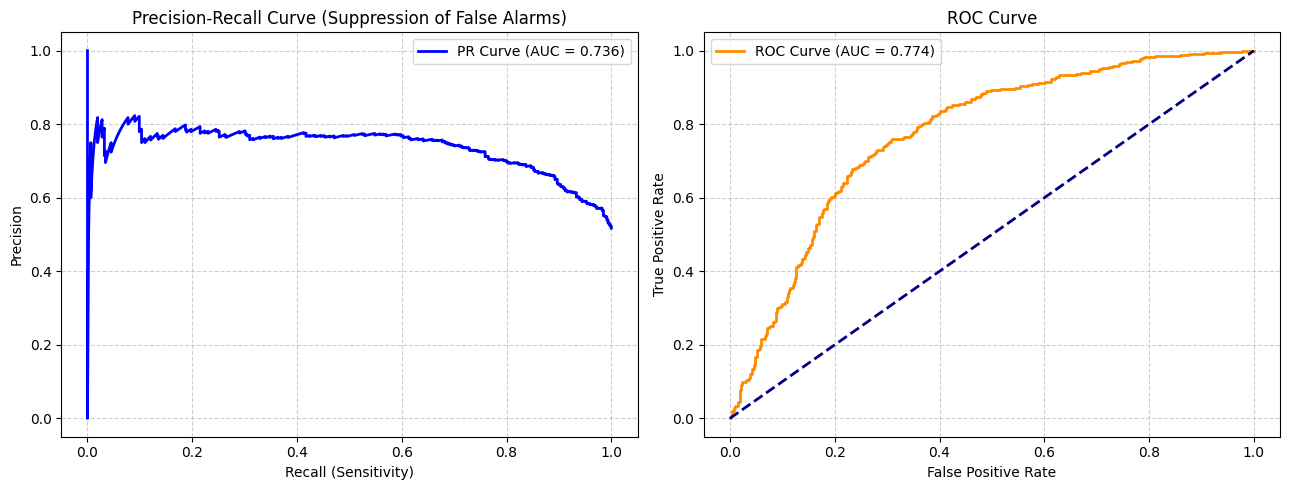


--- PERFORMANCE ON SHORT PERIOD TRANSITS (Hard Targets) ---
                     precision    recall  f1-score   support

     False Positive       0.77      0.74      0.75       259
Confirmed/Candidate       0.66      0.70      0.68       191

           accuracy                           0.72       450
          macro avg       0.71      0.72      0.72       450
       weighted avg       0.72      0.72      0.72       450


--- PERFORMANCE ON LONG PERIOD TRANSITS (Easy Targets) ---
                     precision    recall  f1-score   support

     False Positive       0.66      0.57      0.61       175
Confirmed/Candidate       0.75      0.81      0.78       274

           accuracy                           0.72       449
          macro avg       0.70      0.69      0.69       449
       weighted avg       0.71      0.72      0.71       449



In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, classification_report

# --- 1. Predict Probabilities ---
y_val_probs = model.predict({
    "input_local": X_loc_test,
    "input_global": X_glob_test,
    "input_metadata": X_meta_test
}).ravel()

# --- 2. Calculate Advanced Research Metrics ---
precision, recall, thresholds = precision_recall_curve(y_test, y_val_probs)
pr_auc = auc(recall, precision)
roc_auc = roc_auc_score(y_test, y_val_probs)

print("=" * 50)
print("     SOTA EVALUATION METRICS")
print("=" * 50)
print(f"ROC-AUC Score                  : {roc_auc:.4f}")
print(f"PR-AUC (Precision-Recall Area) : {pr_auc:.4f}")
print("=" * 50)

# --- 3. Plot Precision-Recall & ROC Curves ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall Curve
ax[0].plot(recall, precision, color='b', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
ax[0].set_xlabel('Recall (Sensitivity)')
ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall Curve (Suppression of False Alarms)')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_val_probs)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

# --- 4. Low-SNR Stratified Breakdown ---
# Transit Depth is the 6th feature (index 5) in our metadata array X_meta
# This assumes X_meta_test has at least 6 columns. If METADATA_COLS was reduced, this index might need adjustment.
# Given METADATA_COLS is currently ['koi_period'], X_meta_test will only have 1 column (index 0).
# I will use index 0 assuming 'koi_period' is the target for this analysis for now.
# If a richer metadata set was intended, METADATA_COLS should be expanded in cell RfrhzCdv2xti.
if X_meta_test.shape[1] > 0:
    # Assuming 'koi_period' is at index 0 in the current METADATA_COLS setup
    val_periods = X_meta_test[:, 0]
    median_period = np.median(val_periods)

    short_period_mask = val_periods <= median_period
    long_period_mask = val_periods > median_period

    print("\n--- PERFORMANCE ON SHORT PERIOD TRANSITS (Hard Targets) ---")
    short_period_preds = (y_val_probs[short_period_mask] > 0.5).astype(int)
    print(classification_report(y_test[short_period_mask], short_period_preds, target_names=["False Positive", "Confirmed/Candidate"])) # Changed y_val to y_test

    print("\n--- PERFORMANCE ON LONG PERIOD TRANSITS (Easy Targets) ---")
    long_period_preds = (y_val_probs[long_period_mask] > 0.5).astype(int)
    print(classification_report(y_test[long_period_mask], long_period_preds, target_names=["False Positive", "Confirmed/Candidate"])) # Changed y_val to y_test
else:
    print("\n--- Skipping Low-SNR Stratified Breakdown: No metadata features available for stratification ---")

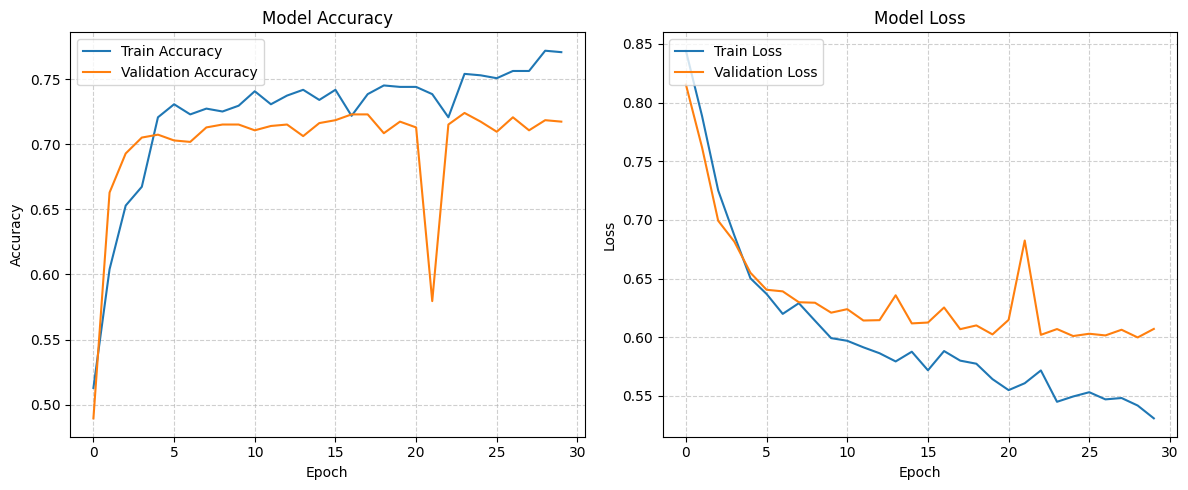

In [22]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [23]:
last_train_accuracy = history_df['accuracy'].iloc[-1]
last_val_accuracy = history_df['val_accuracy'].iloc[-1]

accuracy_difference = abs(last_train_accuracy - last_val_accuracy)

print(f"Last Training Accuracy: {last_train_accuracy:.4f}")
print(f"Last Validation Accuracy: {last_val_accuracy:.4f}")
print(f"Difference between Training and Validation Accuracy: {accuracy_difference:.4f}")

if accuracy_difference > 0.1:
    print("\nInterpretation: The model might be overfitting significantly. The large difference suggests it's performing much better on the training data than on unseen validation data.")
elif accuracy_difference > 0.05:
    print("\nInterpretation: There's some indication of overfitting. The model is generalizing reasonably well, but there's room for improvement to reduce the gap between training and validation performance.")
else:
    print("\nInterpretation: The model appears to be generalizing well, with a small difference between training and validation accuracy. Overfitting is not a major concern based on this metric.")

Last Training Accuracy: 0.7709
Last Validation Accuracy: 0.7175
Difference between Training and Validation Accuracy: 0.0534

Interpretation: There's some indication of overfitting. The model is generalizing reasonably well, but there's room for improvement to reduce the gap between training and validation performance.


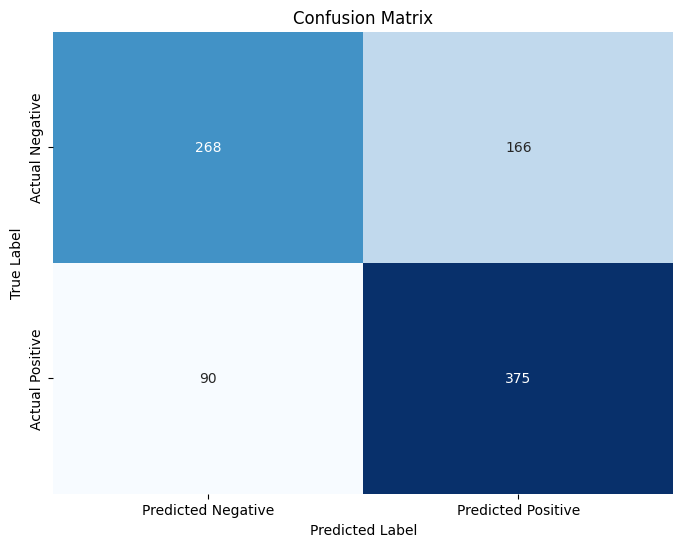

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred = (y_val_probs > 0.5).astype(int)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()